In [129]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [130]:
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.pyplot import pie,axis,show
%matplotlib inline

In [131]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],count=None):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    for i in range(count):
        dfi = df.loc[str(i),:]
        axis('equal')
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        pie(dfi, labels=labels,startangle=0)
        show()

def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    rows = max(int(count/2),1)
    cols = 2 if count>1 else 1
    figsize = tuple([ figdim*rows for _ in range(rows) ])
    fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
    for i in range(count):
        dfi = df.loc[str(i),:]
        ax = fig.add_subplot(rows,cols,(i%cols)+1)
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
        ax.axis('equal')

def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op
    
def get_int_info(int_dict):
    res = {}
    #for k in int_dict.keys():
        #int_dict[k]
        #res[k] = 00

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=d[k]['info']
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

In [143]:
drop_columns = True
drop_re=['min','max'] #drop all columns that have these words
dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))
dfdm,dfex = dfs

output_dict = read_dict(output_data_dict_file)

dts = list(map(get_int_info,get_intervals_data()))
ext_info,det_info = list(map(info_det,dts))

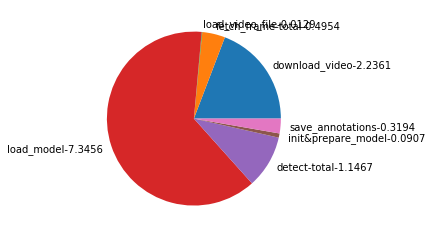

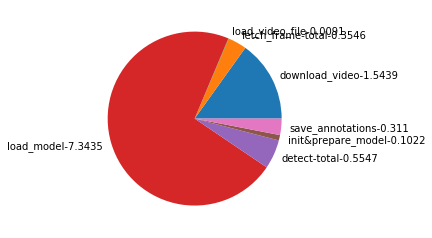

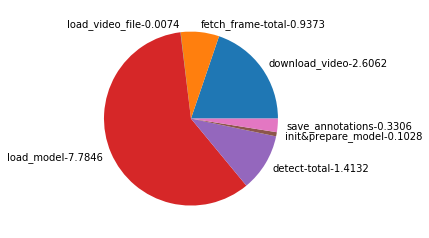

In [133]:
plot_pie_chart(dfex,['name','index','input_file','Total_time','video_duration','video_file_size'])

In [134]:
print(dfex.columns,'\n',dfdm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-total', 'load_video_file', 'load_model', 'detect-total',
       'init&prepare_model', 'save_annotations', 'fetch_frame-avg',
       'video_duration', 'video_file_size', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-avg', 'load_model', 'import_deps', 'detect-total',
       'init_model', 'video_duration', 'video_file_size', 'index'],
      dtype='object')


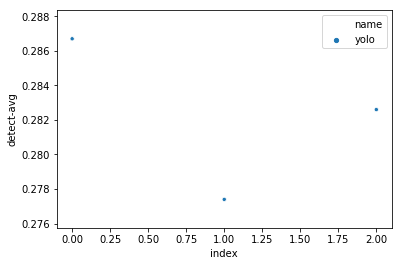

In [135]:
sns.scatterplot(data=dfex,x='index',y='detect-avg',hue='name',size='name')

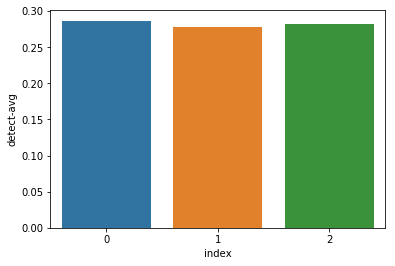

In [136]:
sns.barplot(x='index',y='detect-avg',data=dfex)

In [145]:
v = list_detections(output_dict)
c,s = count_elems(v)
print(s)

{'1': 3, '0': 17, '2': 19}


In [149]:
pd.DataFrame(det_info)

ValueError: arrays must all be same length